## Connect to BigQuery

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

client = bigquery.Client()

query = """
SELECT *
FROM `civil-partition-489110-t9.customer_retention.mart_customer_retention`
"""

df = client.query(query).to_dataframe()

print("Shape:", df.shape)
df.head()

Shape: (99441, 9)


,customer_unique_id,order_id,purchase_at,total_revenue,first_purchase_at,previous_purchase_at,order_sequence,customer_type,days_since_last_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05-10 10:56:27+00:00,129.90,2018-05-10 10:56:27+00:00,NaT,1,New,<NA>
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05-07 11:11:27+00:00,18.90,2018-05-07 11:11:27+00:00,NaT,1,New,<NA>
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03-10 21:05:03+00:00,69.00,2017-03-10 21:05:03+00:00,NaT,1,New,<NA>
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10-12 20:29:41+00:00,25.99,2017-10-12 20:29:41+00:00,NaT,1,New,<NA>
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11-14 19:45:42+00:00,180.00,2017-11-14 19:45:42+00:00,NaT,1,New,<NA>


## Basic Data Cleaning

### * Ensure correct datatypes

In [2]:
df['purchase_at'] = pd.to_datetime(df['purchase_at'])
df['total_revenue'] = pd.to_numeric(df['total_revenue'], errors='coerce')

### * Remove invalid revenue

In [3]:
df_clean = df[df['total_revenue'] > 0].copy()

print("After cleaning:", df_clean.shape)

After cleaning: (98666, 9)


### * Check for nulls

In [4]:
print(df_clean.isnull().sum())

customer_unique_id              0
order_id                        0
purchase_at                     0
total_revenue                   0
first_purchase_at               0
previous_purchase_at        95388
order_sequence                  0
customer_type                   0
days_since_last_purchase    95388
dtype: int64


## Build RFM Table

### * Define Snapshot Date

In [5]:
snapshot_date = df_clean['purchase_at'].max() + pd.Timedelta(days=1)

### * Aggregate to customer level

In [6]:
rfm = df_clean.groupby('customer_unique_id').agg({
    'purchase_at': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'total_revenue': 'sum'
}).reset_index()

rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

print("RFM Shape:", rfm.shape)
rfm.head()

RFM Shape: (95420, 4)


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90
2,0000f46a3911fa3c0805444483337064,542,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,293,1,180.00


## Validate Distributions

In [7]:
print(rfm.describe())
print(rfm['Frequency'].value_counts())

            Recency     Frequency      Monetary
count  95420.000000  95420.000000  95420.000000
mean     243.600377      1.034018    142.440198
std      153.160320      0.211234    217.656355
min        1.000000      1.000000      0.850000
25%      119.000000      1.000000     47.900000
50%      224.000000      1.000000     89.900000
75%      353.000000      1.000000    155.000000
max      729.000000     16.000000  13440.000000
Frequency
1     92507
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64


## RFM Scoring (Corrected for Skew)

### * Recency Score (lower = better)

In [8]:
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
).astype(int)

### * Monetary Score

In [9]:
rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
).astype(int)

### * Frequency Score (Rule-Based for This Dataset)

In [10]:
def frequency_score(x):
    if x == 1:
        return 1
    elif x == 2:
        return 2
    elif x <= 4:
        return 3
    else:
        return 4

rfm['F_score'] = rfm['Frequency'].apply(frequency_score)

## Create Combined RFM Score

In [11]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

## Professional Segmentation Logic

In [12]:
def segment_customer(row):
    
    if row['R_score'] >= 3 and row['F_score'] >= 3:
        return "Champions"
    
    elif row['R_score'] >= 3 and row['M_score'] >= 3:
        return "High Value Recent"
    
    elif row['F_score'] >= 3:
        return "Loyal"
    
    elif row['R_score'] <= 2 and row['M_score'] >= 3:
        return "At Risk High Value"
    
    else:
        return "Low Value / One-time"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

## Segment Distribution

Segment
Low Value / One-time    48838
High Value Recent       23673
At Risk High Value      22669
Champions                 151
Loyal                      89
Name: count, dtype: int64


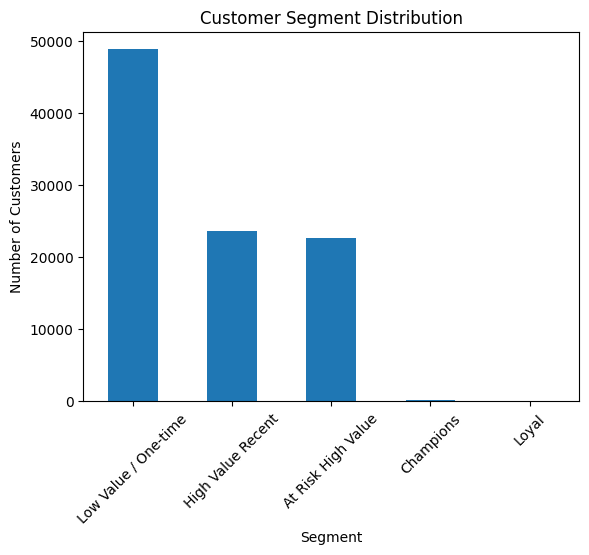

In [13]:
segment_counts = rfm['Segment'].value_counts()

print(segment_counts)

segment_counts.plot(kind='bar')
plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

## Business Summary Table

In [14]:
segment_summary = rfm.groupby('Segment').agg({
    'Monetary': ['sum', 'mean'],
    'Frequency': 'mean',
    'Recency': 'mean'
}).sort_values(('Monetary','sum'), ascending=False)

segment_summary

Monetary             Frequency     Recency
                             sum        mean      mean        mean
Segment                                                           
High Value Recent     5617479.24  237.294776  1.051155  117.379251
At Risk High Value    5511936.29  243.148630  1.043451  369.741850
Low Value / One-time  2361033.30   48.344185  1.009767  246.418649
Champions               67312.02  445.774967  3.529801  108.509934
Loyal                   33882.85  380.706180  3.146067  370.471910

## Save Results

### * Save to CSV

In [15]:
rfm.to_csv("rfm_segmentation.csv", index=False)

### * Push Back to BigQuery

In [16]:
from pandas_gbq import to_gbq

to_gbq(
    rfm,
    destination_table="customer_retention.rfm_segmentation",
    project_id="civil-partition-489110-t9",
    if_exists="replace"
)

#### Which segment has the highest count?

In [17]:
rfm['Segment'].value_counts()

Segment
Low Value / One-time    48838
High Value Recent       23673
At Risk High Value      22669
Champions                 151
Loyal                      89
Name: count, dtype: int64

#### Which segment generates the highest revenue?

In [18]:
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

Segment
High Value Recent       5617479.24
At Risk High Value      5511936.29
Low Value / One-time    2361033.30
Champions                 67312.02
Loyal                     33882.85
Name: Monetary, dtype: float64

## CHURN PROBABILITY MODEL

In [19]:
snapshot_date = df_clean['purchase_at'].max() + pd.Timedelta(days=1)

# Customer level aggregation
churn_df = df_clean.groupby('customer_unique_id').agg({
    'purchase_at': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'total_revenue': 'sum'
}).reset_index()

churn_df.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

# Churn definition
churn_df['Churn'] = np.where(churn_df['Recency'] > 90, 1, 0)

churn_df.head()

,customer_unique_id,Recency,Frequency,Monetary,Churn
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90,1
2,0000f46a3911fa3c0805444483337064,542,1,69.00,1
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99,1
4,0004aac84e0df4da2b147fca70cf8255,293,1,180.00,1


## Prepare Features

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = churn_df[['Recency', 'Frequency', 'Monetary']]
y = churn_df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

## Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5378
           1       1.00      1.00      1.00     23248

    accuracy                           1.00     28626
   macro avg       0.99      1.00      1.00     28626
weighted avg       1.00      1.00      1.00     28626

ROC-AUC: 0.9999995281047381


## Attach Churn Probability

In [25]:
churn_df['Churn_Probability'] = model.predict_proba(X_scaled)[:,1]
churn_df.sort_values('Churn_Probability', ascending=False).head()

,customer_unique_id,Recency,Frequency,Monetary,Churn,Churn_Probability
95419,ffffd2657e2aad2907e67c3e9daecbeb,489,1,56.99,1,1.0
95417,ffff371b4d645b6ecea244b27531430a,573,1,89.90,1,1.0
95415,fffcf5a5ff07b0908bd4e2dbc735a684,452,1,1570.00,1,1.0
2,0000f46a3911fa3c0805444483337064,542,1,69.00,1,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99,1,1.0


## REVENUE FORECAST (Next 3 Months)

#### * Monthly Aggregation

In [26]:
df_clean['YearMonth'] = df_clean['purchase_at'].dt.to_period('M')

monthly_revenue = df_clean.groupby('YearMonth')['total_revenue'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

monthly_revenue

C:\Users\Jeeniya Shakya\AppData\Local\Temp\ipykernel_5760\3229968336.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_clean['YearMonth'] = df_clean['purchase_at'].dt.to_period('M')


,YearMonth,total_revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02
5,2017-03,374344.30
6,2017-04,359927.23
7,2017-05,506071.14
8,2017-06,433038.60
9,2017-07,498031.48


### * Convert to Numeric Time Index

In [27]:
monthly_revenue['TimeIndex'] = range(len(monthly_revenue))

### * Linear Regression Forecast

In [28]:
from sklearn.linear_model import LinearRegression

X = monthly_revenue[['TimeIndex']]
y = monthly_revenue['total_revenue']

ts_model = LinearRegression()
ts_model.fit(X, y)

# Predict next 3 months
future_index = np.array([
    len(monthly_revenue),
    len(monthly_revenue)+1,
    len(monthly_revenue)+2
]).reshape(-1,1)

future_pred = ts_model.predict(future_index)

future_pred

C:\Users\Jeeniya Shakya\analytics_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1012006.0751087 , 1047661.08211739, 1083316.08912609])

### * Plot

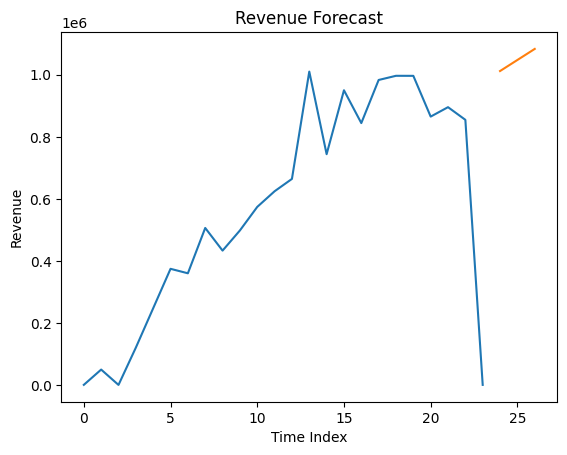

In [29]:
plt.figure()
plt.plot(monthly_revenue['TimeIndex'], y)
plt.plot(future_index, future_pred)
plt.title("Revenue Forecast")
plt.xlabel("Time Index")
plt.ylabel("Revenue")
plt.show()

## A/B TEST SIMULATION

## Business Setup

### * Group A → 10% discount

### * Group B → Free shipping

#### Metric → Revenue per customer

#### * Simulate Data

In [30]:
np.random.seed(42)

group_A = np.random.normal(loc=100, scale=20, size=1000)  # discount
group_B = np.random.normal(loc=110, scale=20, size=1000)  # free shipping

#### * T-Test

In [31]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(group_A, group_B)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -12.477026028717438
P-value: 1.849216934841511e-34


#### * Decision Rule

In [32]:
if p_value < 0.05:
    print("Statistically Significant Difference")
else:
    print("No Significant Difference")

Statistically Significant Difference


# Churn Model

In [33]:
print("Churn Rate:")
print(churn_df['Churn'].value_counts(normalize=True))

Churn Rate:
Churn
1    0.812178
0    0.187822
Name: proportion, dtype: float64


In [34]:
high_risk = churn_df[
    (churn_df['Churn_Probability'] > 0.7) &
    (churn_df['Monetary'] > churn_df['Monetary'].median())
]

high_risk.head()

,customer_unique_id,Recency,Frequency,Monetary,Churn,Churn_Probability
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.9,1,0.993681
4,0004aac84e0df4da2b147fca70cf8255,293,1,180.0,1,1.000000
5,0004bd2a26a76fe21f786e4fbd80607f,151,1,154.0,1,0.999995
7,00053a61a98854899e70ed204dd4bafe,187,1,382.0,1,1.000000
8,0005e1862207bf6ccc02e4228effd9a0,548,1,135.0,1,1.000000


# Revenue Forecast — Sanity Check

In [35]:
from sklearn.metrics import r2_score

pred_train = ts_model.predict(monthly_revenue[['TimeIndex']])
print("R²:", r2_score(y, pred_train))

R²: 0.49966244743906596


# A/B Test

In [36]:
print("Mean A:", group_A.mean())
print("Mean B:", group_B.mean())

Mean A: 100.38664111644651
Mean B: 111.41672474498311
